In [4]:
import os
import sys
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt

sys.path.append(os.path.abspath(".."))
from src.preprocessing import build_dataset, IMG_SIZE, BATCH_SIZE, SEED

In [9]:
TRAIN_DIR = "../dataset/train"
TEST_DIR = "../dataset/test"

print("Train directory:", TRAIN_DIR)
print("Test directory:", TEST_DIR)

Train directory: ../dataset/train
Test directory: ../dataset/test


In [10]:
class_names = sorted([
    name for name in os.listdir(TRAIN_DIR)
    if os.path.isdir(os.path.join(TRAIN_DIR, name))
])

class_to_index = {
    class_name: index
    for index, class_name in enumerate(class_names)
}

print("Classes:", class_names)
print("Class mapping:", class_to_index)

Classes: ['10_rupee', '1_rupee', '2_rupee', '5_rupee']
Class mapping: {'10_rupee': 0, '1_rupee': 1, '2_rupee': 2, '5_rupee': 3}


In [11]:
# function to collect images
def get_image_paths_and_labels(directory):
    image_paths = []
    labels = []

    for class_name in class_names:
        class_dir = os.path.join(directory, class_name)

        for file_name in os.listdir(class_dir):
            if file_name.lower().endswith((".jpg", ".jpeg", ".png", ".bmp")):
                image_paths.append(
                    os.path.join(class_dir, file_name)
                )
                labels.append(class_to_index[class_name])

    return image_paths, labels

In [12]:
train_paths, train_labels = get_image_paths_and_labels(TRAIN_DIR)
test_paths, test_labels= get_image_paths_and_labels(TEST_DIR)

print("Training Images:", len(train_paths))
print("test images: ", len(test_paths))

Training Images: 510
test images:  150


In [15]:
VALIDATION_DIR = "../dataset/validation"

print("Validation directory:", VALIDATION_DIR)

Validation directory: ../dataset/validation


In [16]:
val_paths, val_labels = get_image_paths_and_labels(VALIDATION_DIR)

print("Training images:", len(train_paths))
print("Validation images:", len(val_paths))
print("Test images:", len(test_paths))

Training images: 510
Validation images: 120
Test images: 150


In [17]:
train_dataset = build_dataset(
    train_paths,
    train_labels,
    is_training=True
)

val_dataset = build_dataset(
    val_paths,
    val_labels,
    is_training=False
)

test_dataset = build_dataset(
    test_paths,
    test_labels,
    is_training=False
)

print("Train dataset created.")
print("Validation dataset created.")
print("Test dataset created.")

Train dataset created.
Validation dataset created.
Test dataset created.


In [18]:
for images, labels in train_dataset.take(1):

    print("Train batch shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Data type:", images.dtype)
    print("Minimum pixel value:", tf.reduce_min(images).numpy())
    print("Maximum pixel value:", tf.reduce_max(images).numpy())

Train batch shape: (32, 128, 128, 3)
Labels shape: (32,)
Data type: <dtype: 'float32'>
Minimum pixel value: 0.0032419646
Maximum pixel value: 0.99999994


In [48]:
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(128, 128, 3)),

    tf.keras.layers.Conv2D(32, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Conv2D(64, (3, 3), activation="relu"),
    tf.keras.layers.MaxPooling2D((2, 2)),

    tf.keras.layers.Flatten(),

    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(4, activation="softmax")
])

model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_14 (Conv2D)              │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_14 (MaxPooling2D) │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_15 (Conv2D)              │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_15 (MaxPooling2D) │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_5 (Flatten)             │ (None, 57600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 128)            │     7,372,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,392,836 (28.20 MB)

 Trainable params: 7,392,836 (28.20 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
# model.summary()

In [ ]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

# model.compile(
#     optimizer=tf.keras.optimizers.Adam(learning_rate=0.0005),
#     loss="sparse_categorical_crossentropy",
#     metrics=["accuracy"]
# )

In [22]:
print("Model compiled successfully.")
print("Optimizer: Adam")
print("Loss: Sparse Categorical Crossentropy")
print("Metric: Accuracy")

Model compiled successfully.
Optimizer: Adam
Loss: Sparse Categorical Crossentropy
Metric: Accuracy


In [ ]:
# Train the CNN
EPOCHS = 25


history = model.fit(
    train_dataset,
    validation_data=val_dataset,
    epochs=EPOCHS,
    class_weight=class_weight_dict
)

Epoch 1/25


16/16 ━━━━━━━━━━━━━━━━━━━━ 15s 333ms/step - accuracy: 0.2020 - loss: 1.8579 - val_accuracy: 0.2833 - val_loss: 1.3739
Epoch 2/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 314ms/step - accuracy: 0.3745 - loss: 1.3703 - val_accuracy: 0.2583 - val_loss: 1.3290
Epoch 3/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 395ms/step - accuracy: 0.3902 - loss: 1.3076 - val_accuracy: 0.4167 - val_loss: 1.1665
Epoch 4/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 314ms/step - accuracy: 0.4118 - loss: 1.2170 - val_accuracy: 0.5000 - val_loss: 1.0084
Epoch 5/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 13s 304ms/step - accuracy: 0.4824 - loss: 1.1512 - val_accuracy: 0.5583 - val_loss: 0.9492
Epoch 6/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 292ms/step - accuracy: 0.4725 - loss: 1.1114 - val_accuracy: 0.4333 - val_loss: 1.0950
Epoch 7/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 12s 318ms/step - accuracy: 0.5275 - loss: 1.0606 - val_accuracy: 0.6167 - val_loss: 0.8382
Epoch 8/25
16/16 ━━━━━━━━━━━━━━━━━━━━ 14s 371ms/step - accuracy: 0.5471 - loss: 1.0649 - val_accuracy: 0.691

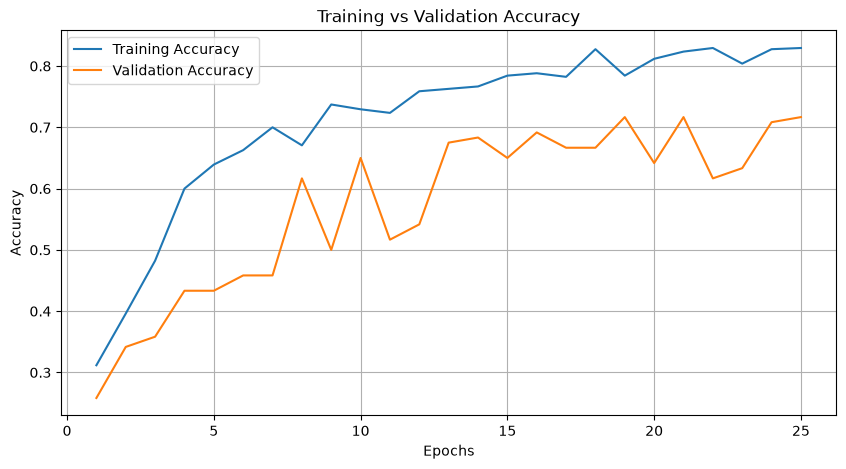

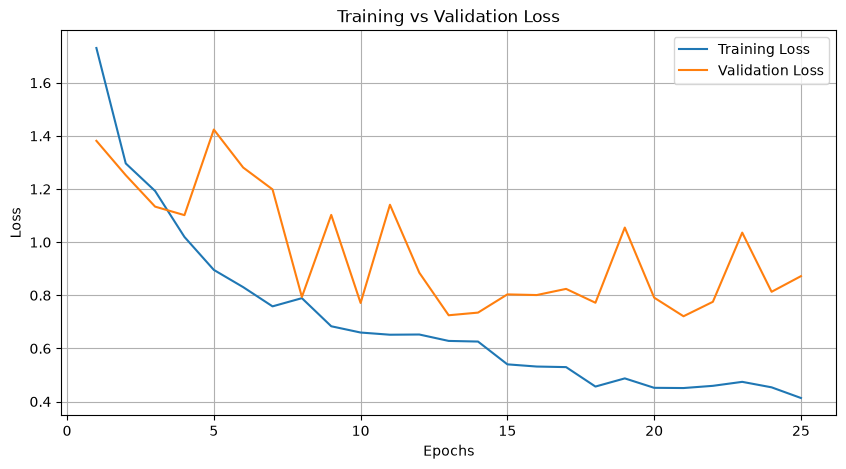

In [24]:
import matplotlib.pyplot as plt

# Get training history
train_accuracy = history.history["accuracy"]
val_accuracy = history.history["val_accuracy"]

train_loss = history.history["loss"]
val_loss = history.history["val_loss"]

epochs_range = range(1, len(train_accuracy) + 1)


# ============================================================
# Accuracy Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, train_accuracy, label="Training Accuracy")
plt.plot(epochs_range, val_accuracy, label="Validation Accuracy")

plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title("Training vs Validation Accuracy")

plt.legend()
plt.grid(True)
plt.show()


# ============================================================
# Loss Curve
# ============================================================

plt.figure(figsize=(10, 5))

plt.plot(epochs_range, train_loss, label="Training Loss")
plt.plot(epochs_range, val_loss, label="Validation Loss")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")

plt.legend()
plt.grid(True)
plt.show()

In [25]:
# ============================================================
# STEP 1.4 — SAVE THE TRAINED MODEL
# ============================================================

import os

MODEL_PATH = "../models/coin_classifier.keras"

# Create models directory if it doesn't exist
os.makedirs("../models", exist_ok=True)

# Save the trained model
model.save(MODEL_PATH)

print("Model saved successfully!")
print("Path:", MODEL_PATH)

Model saved successfully!
Path: ../models/coin_classifier.keras


========================================================CNN IMPROVEMENT=====================================================================

In [26]:
from collections import Counter

print("Training class distribution:")

counts = Counter(train_labels)

for class_name, label in class_to_index.items():
    print(f"{class_name}: {counts[label]}")

Training class distribution:
10_rupee: 120
1_rupee: 150
2_rupee: 60
5_rupee: 180


In [27]:
from collections import Counter

print("Validation class distribution:")

val_counts = Counter(val_labels)

for class_name, label in class_to_index.items():
    print(f"{class_name}: {val_counts[label]}")

Validation class distribution:
10_rupee: 30
1_rupee: 30
2_rupee: 30
5_rupee: 30


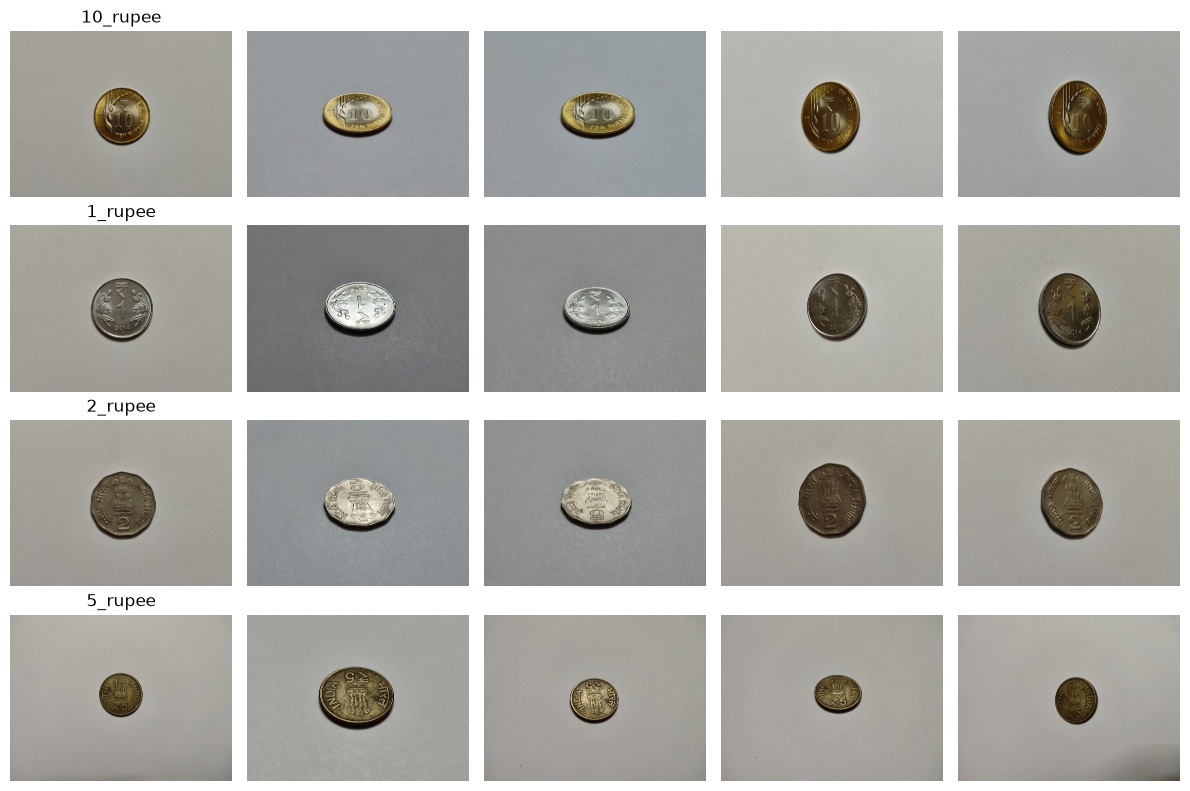

In [28]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

for class_name, label in class_to_index.items():
    indices = [i for i, x in enumerate(train_labels) if x == label]

    for j, idx in enumerate(indices[:5]):
        image = tf.io.read_file(train_paths[idx])
        image = tf.image.decode_jpeg(image, channels=3)

        plt.subplot(4, 5, list(class_to_index.keys()).index(class_name) * 5 + j + 1)
        plt.imshow(image)
        plt.axis("off")

        if j == 0:
            plt.title(class_name)

plt.tight_layout()
plt.show()

In [29]:
from sklearn.utils.class_weight import compute_class_weight
import numpy as np

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(train_labels),
    y=train_labels
)

class_weight_dict = dict(enumerate(class_weights))

print("Class weights:")

for class_name, label in class_to_index.items():
    print(f"{class_name}: {class_weight_dict[label]:.2f}")

Class weights:
10_rupee: 1.06
1_rupee: 0.85
2_rupee: 2.12
5_rupee: 0.71


In [34]:
import os

MODEL_PATH = "../models/coin_classifier_class_weighted.keras"

os.makedirs("../models", exist_ok=True)

model.save(MODEL_PATH)

print("Class-weighted model saved successfully!")
print("Path:", MODEL_PATH)

Class-weighted model saved successfully!
Path: ../models/coin_classifier_class_weighted.keras


In [ ]:
# +++++++++++++++++++++++only for experiment purpose++++++++++++++++++++++++++++++++++++++++++++++

# MODEL_PATH = "../models/coin_classifier_architecture_v2.keras"

# model.save(MODEL_PATH)

# print("Architecture V2 model saved successfully!")
# print("Path:", MODEL_PATH)

Architecture V2 model saved successfully!
Path: ../models/coin_classifier_architecture_v2.keras


In [ ]:
# +++++++++++++++++++++++only for experiment purpose++++++++++++++++++++++++++++++++++++++++++++++
# MODEL_PATH = "../models/coin_classifier_tuned.keras"

# model.save(MODEL_PATH)

# print("Tuned model saved successfully!")
# print("Path:", MODEL_PATH)

Tuned model saved successfully!
Path: ../models/coin_classifier_tuned.keras
